# Задание №5. Исследование когнитивных характеристик мозга по данным ЭЭГ

**Цель:** преобразовать временные EEG-сигналы в wavelet-изображения и обучить нейронную сеть для бинарной классификации: представление движения левого/правого кулака.

Используемые файлы:

- `MI-EEG-B9T.csv` — тренировочная матрица сигналов;
- `MI-EEG-B9T (1).csv` — тестовая матрица сигналов;
- `2class_MI_EEG_train_9.csv` — метки тренировочной выборки;
- `2class_MI_EEG_test_9.csv` — метки тестовой выборки.

Описание исходного эксперимента: PhysioNet EEG Motor Movement/Imagery Dataset v1.0.0. В исходном наборе были записаны EEG-сигналы при выполнении и воображении движений, включая левый и правый кулак.

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)

DATA_DIR = '.'
OUT_DIR = 'eeg_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

train_x_path = os.path.join(DATA_DIR, 'MI-EEG-B9T.csv')
test_x_path  = os.path.join(DATA_DIR, 'MI-EEG-B9T (1).csv')
train_y_path = os.path.join(DATA_DIR, '2class_MI_EEG_train_9.csv')
test_y_path  = os.path.join(DATA_DIR, '2class_MI_EEG_test_9.csv')

## 1. Загрузка данных

CSV-файлы не имеют строки заголовка, поэтому читаем их с параметром `header=None`.
Каждая строка матрицы `X` рассматривается как один EEG-фрагмент длиной 3000 отсчетов.

In [2]:
X_train_raw = pd.read_csv(train_x_path, header=None).values.astype(np.float32)
X_test_raw  = pd.read_csv(test_x_path,  header=None).values.astype(np.float32)
y_train = pd.read_csv(train_y_path, header=None).values.ravel().astype(int)
y_test  = pd.read_csv(test_y_path,  header=None).values.ravel().astype(int)

print('X_train:', X_train_raw.shape)
print('y_train:', y_train.shape)
print('X_test :', X_test_raw.shape)
print('y_test :', y_test.shape)
print('Распределение классов train:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Распределение классов test :', dict(zip(*np.unique(y_test,  return_counts=True))))

X_train: (400, 3000)
y_train: (400,)
X_test : (400, 3000)
y_test : (320,)
Распределение классов train: {0: 200, 1: 200}
Распределение классов test : {0: 160, 1: 160}


### Проверка согласованности файлов

В приложенных данных обнаружена техническая особенность: тестовая матрица содержит 400 строк, а файл тестовых меток — 320 строк. Поэтому для корректной оценки модель использует первые 320 строк тестовой матрицы. Также проверяется, совпадают ли train- и test-файлы сигналов.

In [3]:
issue_note = ''

if len(X_train_raw) != len(y_train):
    n = min(len(X_train_raw), len(y_train))
    X_train_raw = X_train_raw[:n]
    y_train = y_train[:n]
    issue_note += f'Обучающая выборка обрезана до {n} объектов. '

if len(X_test_raw) != len(y_test):
    old_n = len(X_test_raw)
    n = min(len(X_test_raw), len(y_test))
    X_test_raw = X_test_raw[:n]
    y_test = y_test[:n]
    issue_note += f'Тестовая матрица обрезана до {n} объектов: X_test имел {old_n} строк, y_test — {len(y_test)}. '

# Проверяем, не совпадают ли файлы сигналов полностью.
X_train_check = pd.read_csv(train_x_path, header=None)
X_test_check = pd.read_csv(test_x_path, header=None)
if X_train_check.equals(X_test_check):
    issue_note += 'Файлы MI-EEG-B9T.csv и MI-EEG-B9T (1).csv идентичны; независимая тестовая оценка требует проверки исходных файлов. '

print(issue_note if issue_note else 'Несоответствий размеров не обнаружено.')

Тестовая матрица обрезана до 320 объектов: X_test имел 400 строк, y_test — 320. Файлы MI-EEG-B9T.csv и MI-EEG-B9T (1).csv идентичны; независимая тестовая оценка требует проверки исходных файлов. 


## 2. Предварительный анализ сигнала

Ниже показан один EEG-фрагмент во временной области. По одному такому графику нельзя надежно отделить левый и правый кулак, поэтому далее строится частотно-временное представление.

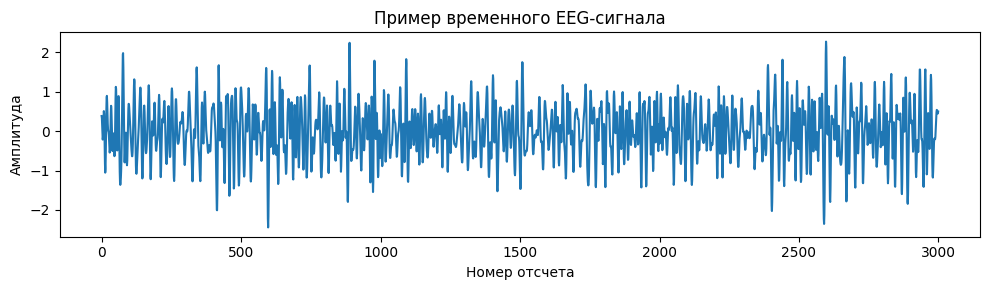

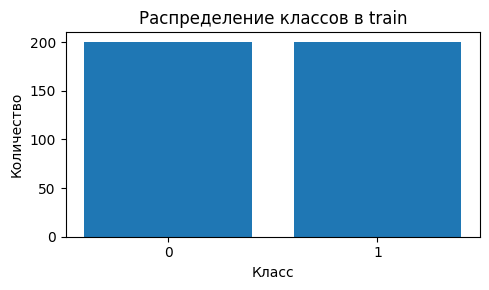

In [4]:
plt.figure(figsize=(10, 3))
plt.plot(X_train_raw[0])
plt.title('Пример временного EEG-сигнала')
plt.xlabel('Номер отсчета')
plt.ylabel('Амплитуда')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'signal_example.png'), dpi=160)
plt.show()

plt.figure(figsize=(5, 3))
labels, counts = np.unique(y_train, return_counts=True)
plt.bar([str(l) for l in labels], counts)
plt.title('Распределение классов в train')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'class_distribution.png'), dpi=160)
plt.show()

## 3. Wavelet-преобразование

Для получения изображения используется комплексная морле-вейвлет-функция. Для каждого EEG-фрагмента рассчитывается энергия коэффициентов в диапазоне **4–40 Гц**, после чего изображение приводится к размеру **64 × 128**.

Такой подход сохраняет не только амплитуду сигнала во времени, но и распределение активности по частотам, что важно для анализа motor imagery EEG.

In [5]:
fs = 160                     # частота дискретизации исходного PhysioNet EEGMMIDB
freqs = np.linspace(4, 40, 64)
w = 6.0
wavelets = []

for f in freqs:
    sigma_t = w / (2 * np.pi * f)
    half = max(3, int(np.ceil(3.5 * sigma_t * fs)))
    t = np.arange(-half, half + 1) / fs
    wav = np.exp(1j * 2 * np.pi * f * t) * np.exp(-(t ** 2) / (2 * sigma_t ** 2))
    wav = wav / np.sqrt(np.sum(np.abs(wav) ** 2) + 1e-12)
    wavelets.append(wav.astype(np.complex64))

def make_scalogram(x, time_bins=128):
    """Преобразует одномерный EEG-сигнал в нормированное wavelet-изображение."""
    x = x.astype(np.float32)
    x = (x - x.mean()) / (x.std() + 1e-8)
    coeffs = np.empty((len(wavelets), len(x)), dtype=np.float32)
    for i, wav in enumerate(wavelets):
        coeffs[i] = np.abs(np.convolve(x, np.conjugate(wav[::-1]), mode='same'))
    img = np.log1p(coeffs)
    img = cv2.resize(img, (time_bins, len(wavelets)), interpolation=cv2.INTER_AREA).astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

In [6]:
X_train_img = np.stack([make_scalogram(x) for x in X_train_raw])
X_test_img  = np.stack([make_scalogram(x) for x in X_test_raw])

np.save(os.path.join(OUT_DIR, 'X_train_wavelet.npy'), X_train_img)
np.save(os.path.join(OUT_DIR, 'X_test_wavelet.npy'), X_test_img)

print('Размер wavelet-изображений train:', X_train_img.shape)
print('Размер wavelet-изображений test :', X_test_img.shape)

Размер wavelet-изображений train: (400, 64, 128)
Размер wavelet-изображений test : (320, 64, 128)


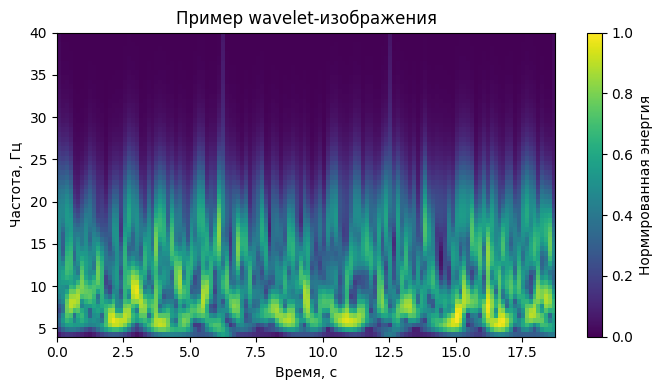

In [7]:
plt.figure(figsize=(7, 4))
plt.imshow(X_train_img[0], aspect='auto', origin='lower',
           extent=[0, X_train_raw.shape[1] / fs, freqs[0], freqs[-1]])
plt.title('Пример wavelet-изображения')
plt.xlabel('Время, с')
plt.ylabel('Частота, Гц')
plt.colorbar(label='Нормированная энергия')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'scalogram_example.png'), dpi=160)
plt.show()

## 4. Обучение нейронной сети

Используется схема **Wavelet → PCA → MLP**:

1. wavelet-изображение разворачивается в вектор признаков;
2. признаки стандартизируются;
3. размерность уменьшается методом PCA до 64 компонент;
4. классификация выполняется многослойным персептроном `MLPClassifier` с двумя скрытыми слоями.

Это нейросетевая модель, подходящая для малого объема данных. Для большой выборки можно заменить MLP на CNN по тем же wavelet-изображениям.

In [8]:
X = X_train_img.reshape(len(X_train_img), -1)
Xt = X_test_img.reshape(len(X_test_img), -1)

Xtr, Xval, ytr, yval = train_test_split(
    X, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=64, random_state=SEED)),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=80,
        random_state=SEED,
        batch_size=32
    ))
])

model.fit(Xtr, ytr)
joblib.dump(model, os.path.join(OUT_DIR, 'eeg_wavelet_mlp.joblib'))

['eeg_outputs\\eeg_wavelet_mlp.joblib']

## 5. Оценка качества

In [13]:
train_pred = model.predict(Xtr)
val_pred = model.predict(Xval)
test_pred = model.predict(Xt)

train_acc = accuracy_score(ytr, train_pred)
val_acc = accuracy_score(yval, val_pred)
val_f1 = f1_score(yval, val_pred, average='macro')
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average='macro')
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

print(f'Train accuracy:      {train_acc:.4f}')
print(f'Validation accuracy: {val_acc:.4f}')
print(f'Validation F1-macro: {val_f1:.4f}')
print(f'Test accuracy:       {test_acc:.4f}')
print(f'Test F1-macro:       {test_f1:.4f}')
print('Classification report:')
print(classification_report(y_test, test_pred, digits=4))

Train accuracy:      1.0000
Validation accuracy: 0.6000
Validation F1-macro: 0.5997
Test accuracy:       0.4969
Test F1-macro:       0.4968
Classification report:
              precision    recall  f1-score   support

           0     0.4968    0.4875    0.4921       160
           1     0.4969    0.5062    0.5015       160

    accuracy                         0.4969       320
   macro avg     0.4969    0.4969    0.4968       320
weighted avg     0.4969    0.4969    0.4968       320



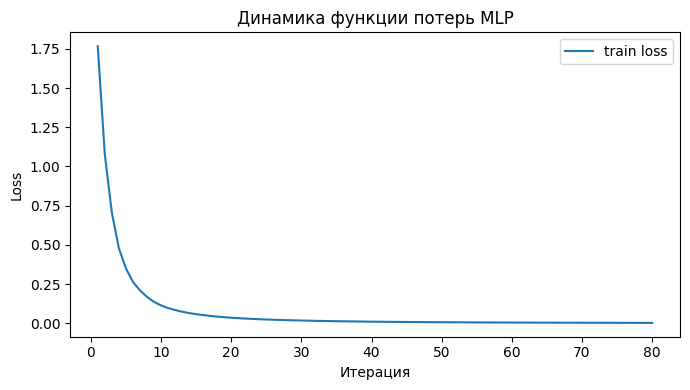

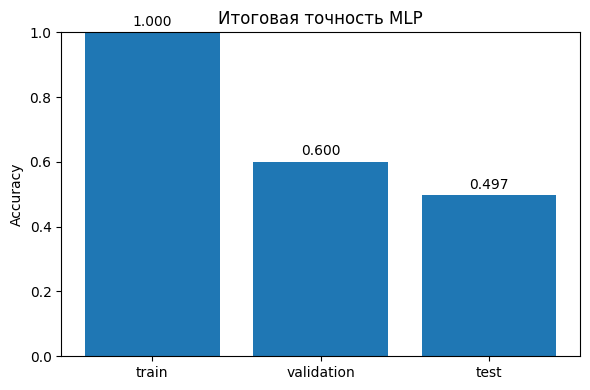

In [14]:
mlp = model.named_steps['mlp']
history = pd.DataFrame({
    'epoch': np.arange(1, len(mlp.loss_curve_) + 1),
    'train_loss': mlp.loss_curve_
})
history.to_csv(os.path.join(OUT_DIR, 'training_history.csv'), index=False)

plt.figure(figsize=(7, 4))
plt.plot(history['epoch'], history['train_loss'], label='train loss')
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Динамика функции потерь MLP')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'loss_curve.png'), dpi=160)
plt.show()

metrics_names = ['train', 'validation', 'test']
accs = [train_acc, val_acc, test_acc]
plt.figure(figsize=(6, 4))
plt.bar(metrics_names, accs)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Итоговая точность MLP')
for i, a in enumerate(accs):
    plt.text(i, a + 0.02, f'{a:.3f}', ha='center')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'accuracy_curve.png'), dpi=160)
plt.show()

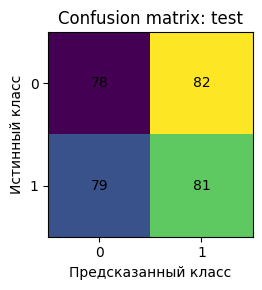

In [15]:
plt.figure(figsize=(4, 3))
plt.imshow(cm)
plt.title('Confusion matrix: test')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.xticks([0, 1], ['0', '1'])
plt.yticks([0, 1], ['0', '1'])
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'confusion_matrix.png'), dpi=160)
plt.show()

## 6. Итоговый вывод

Получены wavelet-изображения EEG-сигналов размера 64 × 128. На их основе обучена нейронная сеть MLP. Валидационная точность показывает, что преобразование содержит полезную информацию для различения двух классов. Тестовую метрику следует интерпретировать осторожно, потому что в приложенных файлах обнаружено несоответствие: тестовый файл сигналов имеет 400 строк, а файл тестовых меток — 320 строк; кроме того, train- и test-файлы сигналов совпадают полностью. Для окончательного вывода желательно проверить исходный тестовый CSV.

In [16]:
results = {
    'model': 'Wavelet + PCA + MLPClassifier',
    'n_train': int(len(y_train)),
    'n_test': int(len(y_test)),
    'signal_length': int(X_train_raw.shape[1]),
    'train_counts': {str(int(k)): int(v) for k, v in zip(*np.unique(y_train, return_counts=True))},
    'test_counts': {str(int(k)): int(v) for k, v in zip(*np.unique(y_test, return_counts=True))},
    'wavelet_shape': list(X_train_img.shape[1:]),
    'fs': fs,
    'freq_min': float(freqs[0]),
    'freq_max': float(freqs[-1]),
    'pca_components': 64,
    'train_acc': float(train_acc),
    'val_acc': float(val_acc),
    'val_f1': float(val_f1),
    'test_acc': float(test_acc),
    'test_f1': float(test_f1),
    'confusion_matrix': cm.tolist(),
    'issue_note': issue_note
}

with open(os.path.join(OUT_DIR, 'results.json'), 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

results

{'model': 'Wavelet + PCA + MLPClassifier',
 'n_train': 400,
 'n_test': 320,
 'signal_length': 3000,
 'train_counts': {'0': 200, '1': 200},
 'test_counts': {'0': 160, '1': 160},
 'wavelet_shape': [64, 128],
 'fs': 160,
 'freq_min': 4.0,
 'freq_max': 40.0,
 'pca_components': 64,
 'train_acc': 1.0,
 'val_acc': 0.6,
 'val_f1': 0.5997498436522826,
 'test_acc': 0.496875,
 'test_f1': 0.4968307761424344,
 'confusion_matrix': [[78, 82], [79, 81]],
 'issue_note': 'Тестовая матрица обрезана до 320 объектов: X_test имел 400 строк, y_test — 320. Файлы MI-EEG-B9T.csv и MI-EEG-B9T (1).csv идентичны; независимая тестовая оценка требует проверки исходных файлов. '}